# ERIS - demand patterns & forecast model evaluation

This notebook explores the sales data behind ERIS and evaluates the forecasting models used in the app.
It runs against the same database as the API (the generated demo company by default) and reuses the
production code in `api/app`, so the numbers here are exactly what the application computes.

1. Demand patterns: trend, weekly and yearly seasonality, festivals, outlets
2. Model comparison from the rolling-origin back-test (`python -m app.evaluation`)
3. A hold-out forecast for one series, all models side by side
4. Demand drivers (rain) and anomaly detection scored against the generator's labelled anomalies

All data is synthetic (see `docs/DATASET.md`); accuracy figures describe this dataset, not a real shop.

In [1]:
import sys, logging, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "api"))
warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.db import SessionLocal
from app.services import analytics as A, forecasting as F
from app.services.holidays import EVENTS

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True})
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
db = SessionLocal()
anchor = A.anchor_date(db)
total = F.load_series(db, F.build_spec(db, "total", None, None), anchor)
print(f"{len(total)} days of sales up to {anchor}, total revenue ₹{total.sum()/1e7:.2f} Cr")

730 days of sales up to 2026-10-01, total revenue ₹10.32 Cr


## 1. Demand patterns
### Daily revenue with a 28-day moving average

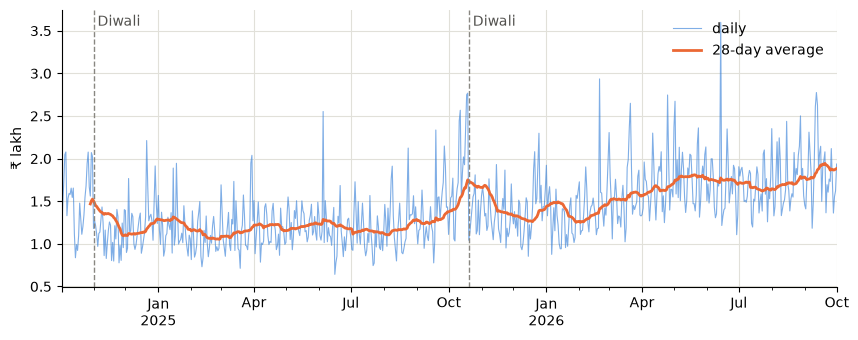

Month-on-month revenue (₹ lakh):
2025-10-01    50.5
2025-11-01    40.8
2025-12-01    43.5
2026-01-01    40.2
2026-02-01    41.1
2026-03-01    49.3
2026-04-01    50.4
2026-05-01    56.5
2026-06-01    50.7
2026-07-01    51.2
2026-08-01    55.3
2026-09-01    55.4
2026-10-01     1.9
Freq: MS


In [2]:
ax = (total / 1e5).plot(color=COLORS[0], lw=0.8, alpha=0.6, label="daily")
(total.rolling(28).mean() / 1e5).plot(ax=ax, color=COLORS[1], lw=2, label="28-day average")
for name, day, *_ in EVENTS:
    if total.index[0] <= pd.Timestamp(day) <= total.index[-1] and name == "Diwali":
        ax.axvline(pd.Timestamp(day), color="#898781", ls="--", lw=1); ax.text(pd.Timestamp(day), ax.get_ylim()[1]*0.95, " Diwali", color="#52514e")
ax.set_ylabel("₹ lakh"); ax.legend(frameon=False); plt.show()
yoy = total.resample("MS").sum()
print("Month-on-month revenue (₹ lakh):"); print((yoy / 1e5).round(1).tail(13).to_string())

### Weekly and yearly seasonality

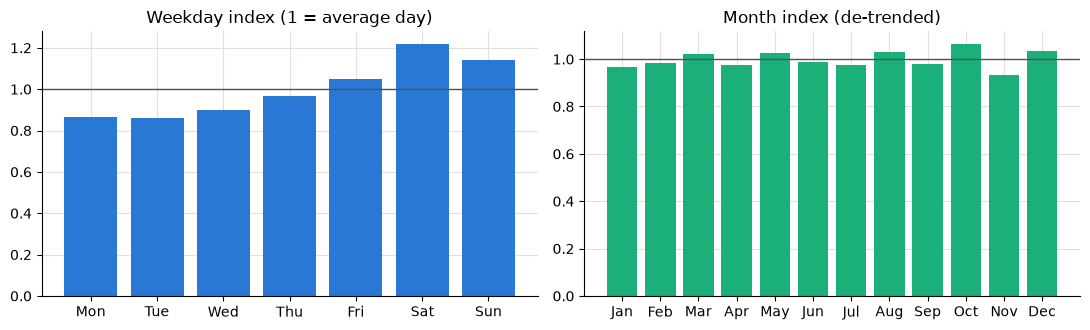

Saturday sells 42% more than Tuesday


In [3]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
dow = total.groupby(total.index.dayofweek).mean() / total.mean()
a.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow.values, color=COLORS[0]); a.axhline(1, color="#52514e", lw=1)
a.set_title("Weekday index (1 = average day)")
detr = total / total.rolling(56, center=True, min_periods=28).mean()
mon = detr.groupby(detr.index.month).mean()
b.bar([pd.Timestamp(2026, m, 1).strftime("%b") for m in mon.index], mon.values, color=COLORS[2]); b.axhline(1, color="#52514e", lw=1)
b.set_title("Month index (de-trended)"); plt.tight_layout(); plt.show()
print(f"Saturday sells {dow.iloc[5]/dow.iloc[1]-1:.0%} more than Tuesday")

### Festival effect on festive categories
Revenue of *Sweets & Festive* in the 12 days before Diwali vs other days - this is why the festival calendar is a model feature.

Average daily sweets revenue: ₹1,819 normally vs ₹5,537 before Diwali (3.0x)


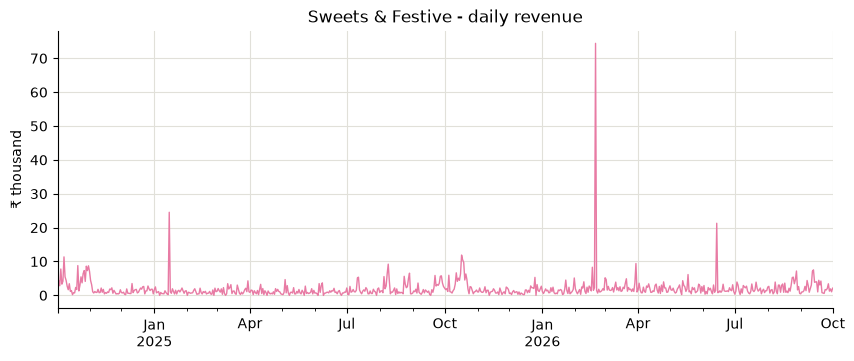

In [4]:
from app.models import Category
from sqlalchemy import select
cat = db.scalar(select(Category).where(Category.name == "Sweets & Festive"))
sweets = F.load_series(db, F.build_spec(db, "category", cat.id, None), anchor)
diwali = [pd.Timestamp(d) for n, d, *_ in EVENTS if n == "Diwali" and sweets.index[0] <= pd.Timestamp(d) <= sweets.index[-1]]
window = pd.Series(False, index=sweets.index)
for d in diwali: window[(sweets.index >= d - pd.Timedelta(days=12)) & (sweets.index <= d)] = True
print(f"Average daily sweets revenue: ₹{sweets[~window].mean():,.0f} normally vs ₹{sweets[window].mean():,.0f} before Diwali "
      f"({sweets[window].mean()/sweets[~window].mean():.1f}x)")
(sweets / 1e3).plot(color=COLORS[4], lw=1); plt.ylabel("₹ thousand"); plt.title("Sweets & Festive - daily revenue"); plt.show()

### Outlets: growth differs by location

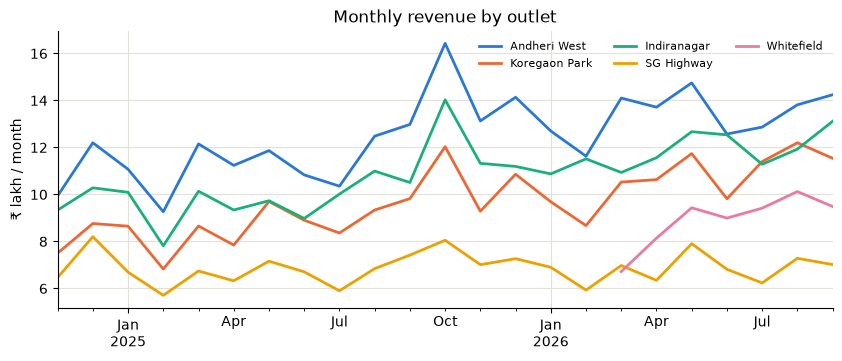

In [5]:
from app.models import Outlet
fig, ax = plt.subplots()
for i, o in enumerate(db.scalars(select(Outlet).order_by(Outlet.id))):
    s = F.load_series(db, F.build_spec(db, "outlet", o.id, None), anchor)
    (s.resample("MS").sum() / 1e5).iloc[1:-1].plot(ax=ax, color=COLORS[i], lw=2, label=o.name)
ax.set_ylabel("₹ lakh / month"); ax.legend(frameon=False, ncol=3, fontsize=8); plt.title("Monthly revenue by outlet"); plt.show()

## 2. Model comparison (rolling-origin back-test)

Results of `python -m app.evaluation`: 25 series (total, 5 outlets, 9 categories, top 10 products), 3 forecast origins
each, 28-day horizon. Each model only sees data before the origin. *ERIS auto* is the production selection rule.

In [6]:
ev = pd.read_csv(Path.cwd().parent / "docs" / "forecast_evaluation.csv")
labels = {"seasonal_naive": "Seasonal naive", "holt_winters": "Holt-Winters", "xgboost": "XGBoost", "prophet": "Prophet", "auto": "ERIS auto"}
table = ev.pivot_table(index="model", columns="scope", values="wape", aggfunc="mean")
table["all"] = ev.groupby("model")["wape"].mean()
table = table.loc[list(labels)].rename(index=labels).round(2)
table

scope,category,outlet,product,total,all
model,,,,,
Seasonal naive,20.97,23.08,18.82,12.15,20.18
Holt-Winters,21.60,21.64,17.43,12.39,19.57
XGBoost,23.09,29.02,18.29,14.83,22.03
Prophet,17.41,20.47,16.14,8.60,17.16
ERIS auto,17.48,20.47,16.37,8.60,17.28


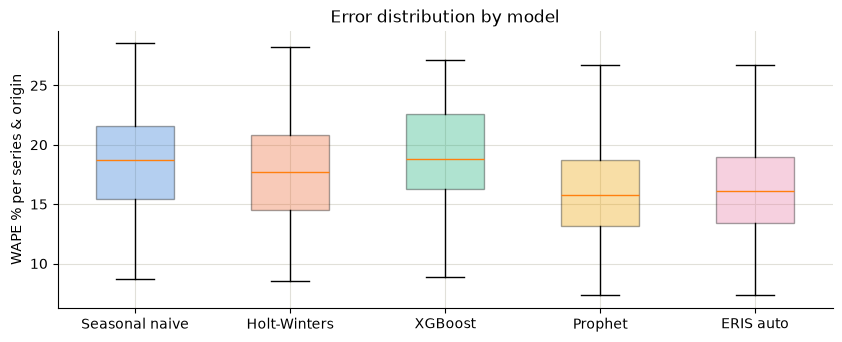

ERIS auto beats the naive baseline in 80% of 75 series/origin pairs; mean error 17.3% vs 20.2%


In [7]:
order = list(labels)
data = [ev.loc[ev.model == m, "wape"].values for m in order]
fig, ax = plt.subplots(figsize=(10, 3.6))
bp = ax.boxplot(data, tick_labels=[labels[m] for m in order], patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], COLORS): patch.set_facecolor(c); patch.set_alpha(0.35)
ax.set_ylabel("WAPE % per series & origin"); ax.set_title("Error distribution by model"); plt.show()
base = ev[ev.model == "seasonal_naive"].set_index(["series", "origin"])["wape"]
auto = ev[ev.model == "auto"].set_index(["series", "origin"])["wape"]
print(f"ERIS auto beats the naive baseline in {(auto < base).mean():.0%} of {len(auto)} series/origin pairs; "
      f"mean error {auto.mean():.1f}% vs {base.mean():.1f}%")

## 3. Hold-out forecast: total revenue, last 28 days
All models trained on data up to 28 days before the end, compared with what actually happened.

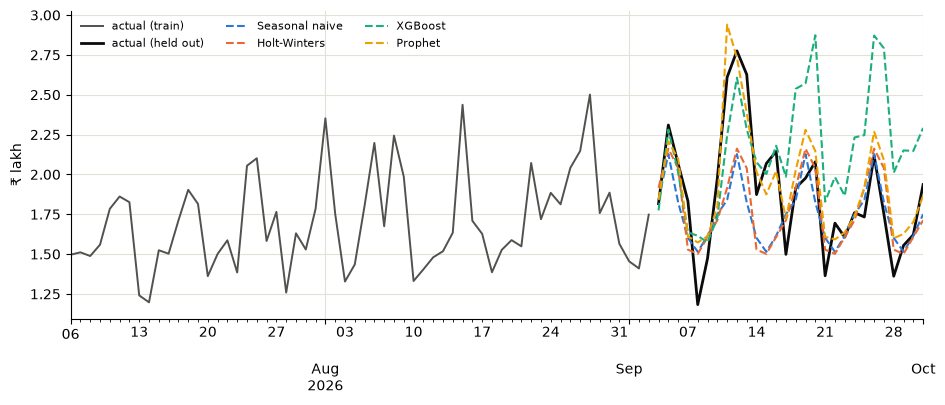

,wape,smape,mae,rmse,bias_pct
model,,,,,
Seasonal naive,12.87,12.90,24234.89,32739.33,-6.89
Holt-Winters,12.25,12.34,23072.28,30443.88,-5.43
XGBoost,20.29,19.06,38208.65,45982.34,14.56
Prophet,8.35,8.57,15728.21,18729.43,3.41


In [8]:
train, test = total.iloc[:-28], total.iloc[-28:]
fig, ax = plt.subplots(figsize=(11, 4))
(train.iloc[-60:] / 1e5).plot(ax=ax, color="#52514e", lw=1.4, label="actual (train)")
(test / 1e5).plot(ax=ax, color="#0b0b0b", lw=2, label="actual (held out)")
spec = F.build_spec(db, "total", None, None)
exog = F.load_exog(db, spec, train, 28)  # promotions, price index, weather (climatology ahead), stockouts
rows = []
for i, m in enumerate(F.available_models()):
    p = pd.Series(F.MODEL_FUNCS[m](train, 28, exog), index=test.index)
    (p / 1e5).plot(ax=ax, color=COLORS[i], lw=1.5, ls="--", label=labels[m])
    rows.append({"model": labels[m], **F._metrics(test.values, p.values)})
ax.set_ylabel("₹ lakh"); ax.legend(frameon=False, ncol=3, fontsize=8); plt.show()
pd.DataFrame(rows).set_index("model")[["wape", "smape", "mae", "rmse", "bias_pct"]].round(2)

## 4. Demand drivers and anomaly detection
### Rain and footfall
Daily revenue divided by its weekday-specific rolling level, against outlet-weighted rainfall. The driver analysis in
the app uses the same association (and labels it as an association, not a cause).

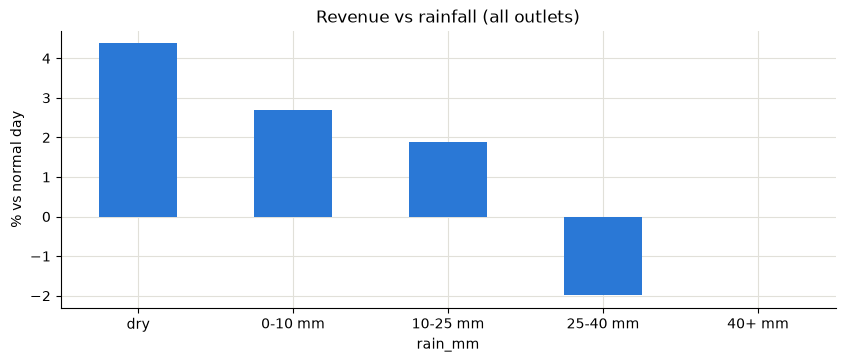

rain_mm
dry         4.4
0-10 mm     2.7
10-25 mm    1.9
25-40 mm   -2.0
40+ mm      0.0
dtype: float64

In [9]:
exo = F.load_exog(db, spec, total, 0).reindex(total.index)
level = total.groupby(total.index.dayofweek).transform(lambda s: s.rolling(5, center=True, min_periods=3).median())
ratio = (total / level).dropna()
rain = exo["rain_mm"].reindex(ratio.index).clip(upper=60)
bins = pd.cut(rain, [-0.1, 0.5, 10, 25, 40, 60], labels=["dry", "0-10 mm", "10-25 mm", "25-40 mm", "40+ mm"])
effect = (ratio.groupby(bins, observed=True).mean() - 1) * 100
effect.plot.bar(color=COLORS[0]); plt.ylabel("% vs normal day"); plt.title("Revenue vs rainfall (all outlets)"); plt.xticks(rotation=0); plt.show()
effect.round(1)

### Anomaly detection vs injected ground truth
The generator injects POS outages, bulk orders, data-entry errors, local events and closures and stores them as labels.
The detector never sees the labels; they are only used here to measure it.

In [10]:
from app.services import anomalies as AN
start = total.index[0].date() + pd.Timedelta(days=60).to_pytimedelta()
found = AN.detect(db, start, anchor)
score = AN.score_against_labels(db, found, start, anchor)
print(f"precision {score['precision']}, recall {score['recall']}, F1 {score['f1']} "
      f"({score['true_positives']} of {score['labelled']} injected anomalies found, {score['false_positives']} other days flagged)")
pd.DataFrame(score["by_kind"]).T.assign(recall=lambda d: (d.detected / d.labelled).round(2))

precision 0.792, recall 0.731, F1 0.76 (19 of 26 injected anomalies found, 5 other days flagged)


,labelled,detected,recall
bulk_order,6,6,1.00
pos_outage,7,5,0.71
local_event,5,1,0.20
closure,3,3,1.00
entry_error,5,4,0.80


In [11]:
lines = AN.suspicious_lines(db, start, anchor)
print(f"{len(lines)} suspicious bill lines (quantity > 20x typical); injected entry errors are caught here even when the day total looks normal")
pd.DataFrame(lines)[["day", "outlet", "product", "quantity", "typical_quantity", "line_total"]].head(10)

5 suspicious bill lines (quantity > 20x typical); injected entry errors are caught here even when the day total looks normal


,day,outlet,product,quantity,typical_quantity,line_total
0,2026-08-06,SG Highway,Whole Wheat Atta 5kg,300.0,1.1,85500.0
1,2025-09-19,Andheri West,Filter Coffee Powder 250g,500.0,1.2,115500.0
2,2025-07-08,Indiranagar,Butter Cookies 300g,300.0,1.0,55200.0
3,2025-06-05,Koregaon Park,Organic Quinoa 500g,500.0,1.2,143500.0
4,2025-03-22,Indiranagar,Sourdough Loaf,300.0,1.2,45900.0


## Conclusions

- Demand has a strong weekly cycle, yearly seasonality (summer beverages, festive season) and large festival
  spikes - Prophet, which models the festival calendar and the external regressors, is the most accurate model
  (about 17% mean WAPE vs 20% for the seasonal-naive baseline).
- The recursive XGBoost model is *less* accurate than the baseline on this data: errors compound over a 28-day
  recursive horizon and a two-year history is short for a tree model. It stays as a challenger and wins on some
  individual series, but production almost always keeps Prophet.
- The 80% prediction band covers about 75% of held-out days, i.e. it is slightly too narrow.
- Picking the "best" model on a single short back-test window chases noise. ERIS therefore uses two folds and keeps
  Prophet unless another model is clearly (>10%) better, which matches the best single model on average while
  adapting where a series behaves differently.
- Product-level daily series are noisy; aggregate series (outlet, category, total) are forecast far more accurately,
  which is why reorder planning adds safety stock based on demand variability.